In [35]:
import os
import sys
from dotenv import load_dotenv
from pathlib import Path
import datetime

import pandas as pd
import numpy as np
from math import exp, sqrt
import random
import matplotlib.pyplot as plt
from optionprice import Option

## 6 デリバティブ取引の理論と実装

In [36]:
# environment variables
env_path = Path("/home/jovyan/.env")
load_dotenv(env_path)

# mounted data directory in container
data_path = Path("/home/jovyan/data/data-main")

print("cwd:", Path.cwd())
print("data_path:", data_path)
print("exists:", data_path.exists())

cwd: /home/jovyan
data_path: /home/jovyan/data/data-main
exists: True


In [37]:
# finance/data/data-main/6_1_fx_swap_data.csv
data = pd.read_csv(data_path / "6_1_fx_swap_data.csv", parse_dates=True).sort_index()
data['Date'] = pd.to_datetime(data['Date'])
# 日時をdatetime型に変換
df = data.set_index('Date')
data_list = ['US1Y', 'JP1Y', 'spot']
df.columns = data_list
df.head()

,US1Y,JP1Y,spot
Date,,,
2018-01-04,1.82,-0.143,112.78
2018-01-05,1.80,-0.144,113.18
2018-01-09,1.78,-0.136,112.57
2018-01-10,1.78,-0.127,111.48
2018-01-11,1.77,-0.127,111.35


In [38]:
# [3]先物為替レート理論値の算出
day1 = 365
day2 = 360
df['fwd'] = df.spot * (1 + df.JP1Y * day1 / 365) / (1 + df.US1Y * day2 / 360)

Text(0, 0.5, 'JPY/USD')

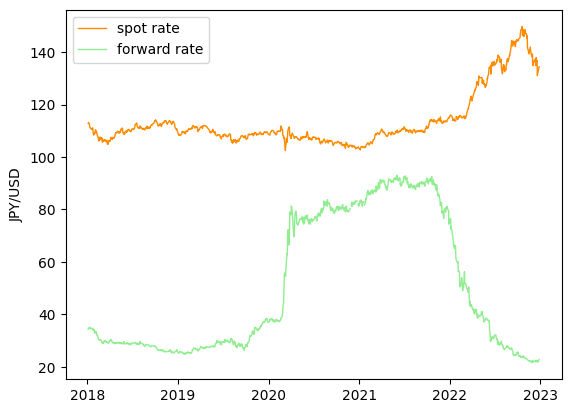

In [39]:
# [4]可視化
plt.plot(df.spot, color='darkorange', label='spot rate', lw=1)
plt.plot(df.fwd, color='lightgreen', label='forward rate', lw=1)
plt.legend()
plt.ylabel('JPY/USD')

## 6.4 オプション取引の理論と実装

In [40]:
# finance/data/data-main/5_nikkei225_data.csv
nikkei = pd.read_csv(data_path / "5_nikkei225_data.csv", parse_dates=True).sort_index()
nikkei = nikkei.set_index('Date')
last_nikkei = nikkei.nikkei[-1]
last_rate = 0.01
d_nikkei = np.log(nikkei.nikkei)
d_nikkei.head()

/tmp/ipykernel_125/2475037140.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_nikkei = nikkei.nikkei[-1]


Date
2021/1/4    10.213116
2021/1/5    10.209450
2021/1/6    10.205662
2021/1/7    10.221582
2021/1/8    10.244913
Name: nikkei, dtype: float64

In [41]:
# [4] 初期値の設定
s0 = last_nikkei
k = 29000
r = last_rate
days = 30
sigma = np.std(d_nikkei)

In [42]:
# [5 - 1]コールオプション価格の算出
some_option = Option(european=True, kind='call', s0=s0, k=k, sigma=sigma, r=r, start='2022-07-23', end='2022-08-22', dv=0)

In [43]:
# [5 - 2]プットオプション価格の算出
some_option = Option(european=True, kind='put', s0=s0, k=k, sigma=sigma, r=r, start='2022-07-23', end='2022-08-22', dv=0)

In [44]:
# [6]算出結果の表示
print(some_option)

Type:           European
Kind:           put
Price initial:  27968.99
Price strike:   29000
Volatility:     4.078735085131192%
Risk free rate: 1.0%
Start Date:     2022-07-23
Expire Date:    2022-08-22
Time span:      30 days
